In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv(r'Data\cac40_clean_format.csv')

# Convert datetime to proper format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Let's examine the structure
print(df.head())
print(df.info())

                   Datetime  Price  Ticker       Value
0 2023-03-13 08:00:00+00:00  Close   AC.PA   29.910000
1 2023-03-13 08:00:00+00:00  Close  ACA.PA   10.668000
2 2023-03-13 08:00:00+00:00  Close   AI.PA  133.545456
3 2023-03-13 08:00:00+00:00  Close  AIR.PA  119.599998
4 2023-03-13 08:00:00+00:00  Close   BN.PA   54.230000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913740 entries, 0 to 913739
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype              
---  ------    --------------   -----              
 0   Datetime  913740 non-null  datetime64[ns, UTC]
 1   Price     913740 non-null  object             
 2   Ticker    913740 non-null  object             
 3   Value     913740 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 27.9+ MB
None


In [14]:
# Pivot the data to get each ticker with proper OHLCV structure
# First, let's filter for specific Price types
ohlcv_df = df.copy()

# Create a proper time series dataframe for each ticker
# This assumes your data has Open, High, Low, Close, Volume in the Price column
pivot_df = pd.pivot_table(
    ohlcv_df, 
    values='Value', 
    index=['Datetime', 'Ticker'], 
    columns=['Price']
).reset_index()

# Flatten the multi-index columns
pivot_df.columns = ['Datetime', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume']

# Sort by ticker and datetime
pivot_df = pivot_df.sort_values(['Ticker', 'Datetime'])

print(pivot_df.head())

                     Datetime Ticker      Close       High        Low  \
0   2023-03-13 08:00:00+00:00  AC.PA  29.910000  30.770000  29.889999   
38  2023-03-13 09:00:00+00:00  AC.PA  29.430000  29.980000  29.360001   
76  2023-03-13 10:00:00+00:00  AC.PA  29.680000  29.680000  29.350000   
114 2023-03-13 11:00:00+00:00  AC.PA  29.450001  29.719999  29.450001   
152 2023-03-13 12:00:00+00:00  AC.PA  29.190001  29.500000  29.080000   

          Open   Volume  
0    30.760000      0.0  
38   29.910000  54303.0  
76   29.410000  58924.0  
114  29.670000  38830.0  
152  29.469999  37615.0  


In [15]:
def add_technical_indicators(df_group):
    # Make sure we have enough data
    if len(df_group) < 30:
        return df_group
        
    # Basic momentum indicators
    # RSI
    delta = df_group['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df_group['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD
    exp1 = df_group['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df_group['Close'].ewm(span=26, adjust=False).mean()
    df_group['MACD'] = exp1 - exp2
    df_group['MACD_Signal'] = df_group['MACD'].ewm(span=9, adjust=False).mean()
    df_group['MACD_Hist'] = df_group['MACD'] - df_group['MACD_Signal']
    
    # Moving averages
    df_group['SMA_20'] = df_group['Close'].rolling(window=20).mean()
    df_group['SMA_50'] = df_group['Close'].rolling(window=50).mean()
    df_group['SMA_200'] = df_group['Close'].rolling(window=200).mean()
    
    # Volatility indicators - ATR
    high_low = df_group['High'] - df_group['Low']
    high_close = abs(df_group['High'] - df_group['Close'].shift())
    low_close = abs(df_group['Low'] - df_group['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    df_group['ATR'] = true_range.rolling(14).mean()
    
    # Bollinger Bands
    df_group['Middle_Band'] = df_group['Close'].rolling(window=20).mean()
    std_dev = df_group['Close'].rolling(window=20).std()
    df_group['Upper_Band'] = df_group['Middle_Band'] + (std_dev * 2)
    df_group['Lower_Band'] = df_group['Middle_Band'] - (std_dev * 2)
    
    # Volume indicators - OBV (On-Balance Volume)
    df_group['OBV'] = (np.sign(df_group['Close'].diff()) * df_group['Volume']).fillna(0).cumsum()
    
    # Returns
    df_group['Daily_Return'] = df_group['Close'].pct_change()
    df_group['5d_Return'] = df_group['Close'].pct_change(periods=5)
    df_group['10d_Return'] = df_group['Close'].pct_change(periods=10)
    
    # Target variable for prediction (next 5-day return - good for swing trading)
    df_group['Target'] = df_group['Close'].pct_change(periods=5).shift(-5)
    
    return df_group

# Apply the function to each ticker group
enhanced_df = pivot_df.groupby('Ticker').apply(add_technical_indicators).reset_index(drop=True)

# Drop rows with NaN values (mainly from the initial calculation of indicators)
enhanced_df = enhanced_df.dropna()

print(enhanced_df.head())

                     Datetime Ticker      Close       High        Low  \
199 2023-04-14 08:00:00+00:00  AC.PA  30.730000  30.920000  30.700001   
200 2023-04-14 09:00:00+00:00  AC.PA  30.760000  30.820000  30.700001   
201 2023-04-14 10:00:00+00:00  AC.PA  30.730000  30.760000  30.639999   
202 2023-04-14 11:00:00+00:00  AC.PA  30.870001  30.870001  30.719999   
203 2023-04-14 12:00:00+00:00  AC.PA  30.900000  30.969999  30.870001   

          Open   Volume        RSI      MACD  MACD_Signal  ...   SMA_200  \
199  30.879999  79601.0  54.263519  0.147713     0.170763  ...  29.44545   
200  30.719999  36715.0  57.936549  0.133333     0.163277  ...  29.44970   
201  30.750000  67292.0  63.478242  0.118154     0.154252  ...  29.45620   
202  30.730000  46294.0  66.400045  0.116083     0.146618  ...  29.46215   
203  30.870001  40021.0  60.377331  0.115531     0.140401  ...  29.46940   

          ATR  Middle_Band  Upper_Band  Lower_Band       OBV  Daily_Return  \
199  0.195714      30.7120

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def prepare_ml_data(df_ticker):
    # Define features and target
    features = ['RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 
                'SMA_20', 'SMA_50', 'SMA_200', 'ATR',
                'Upper_Band', 'Middle_Band', 'Lower_Band', 'OBV',
                'Daily_Return', '5d_Return', '10d_Return',
                'Open', 'High', 'Low', 'Close', 'Volume']
    
    # Create price-based features (normalized to remove scale effects)
    df_ticker['Close_to_SMA20'] = df_ticker['Close'] / df_ticker['SMA_20'] - 1
    df_ticker['Close_to_SMA50'] = df_ticker['Close'] / df_ticker['SMA_50'] - 1
    df_ticker['SMA20_to_SMA50'] = df_ticker['SMA_20'] / df_ticker['SMA_50'] - 1
    
    # Add these new features
    features.extend(['Close_to_SMA20', 'Close_to_SMA50', 'SMA20_to_SMA50'])
    
    # Prepare X and y
    X = df_ticker[features].values
    y = df_ticker['Target'].values
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split data - time-based split (not random)
    train_size = int(len(X_scaled) * 0.7)
    val_size = int(len(X_scaled) * 0.15)
    
    X_train = X_scaled[:train_size]
    y_train = y[:train_size]
    
    X_val = X_scaled[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]
    
    X_test = X_scaled[train_size+val_size:]
    y_test = y[train_size+val_size:]
    
    return X_train, X_val, X_test, y_train, y_val, y_test, scaler, features

# Create time sequences for LSTM
def create_sequences(X, y, time_steps=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

# Apply for a specific ticker
ticker = enhanced_df['Ticker'].unique()[0]
ticker_data = enhanced_df[enhanced_df['Ticker'] == ticker].copy()

X_train, X_val, X_test, y_train, y_val, y_test, scaler, feature_names = prepare_ml_data(ticker_data)

# Create sequences for LSTM
time_steps = 10  # 10 days of historical data to predict next 5-day return
X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps)

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}")
print(f"Testing sequences shape: {X_test_seq.shape}")

Training sequences shape: (3049, 10, 23)
Validation sequences shape: (645, 10, 23)
Testing sequences shape: (647, 10, 23)


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build LSTM model
def build_lstm_model(input_shape):
    model = Sequential([
        # First LSTM layer
        LSTM(100, return_sequences=True, input_shape=input_shape, 
             recurrent_dropout=0.2),
        BatchNormalization(),
        
        # Second LSTM layer
        LSTM(50, return_sequences=False, recurrent_dropout=0.2),
        BatchNormalization(),
        
        # Dense layers
        Dense(25, activation='relu'),
        Dropout(0.2),
        
        # Output layer - regression
        Dense(1)
    ])
    
    # Use mean squared error for regression
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model



In [18]:


# Convert predictions to trading signals
def generate_signals(predictions, threshold=0.01):
    signals = np.zeros_like(predictions)
    signals[predictions >= threshold] = 1  # Buy signal
    signals[predictions <= -threshold] = -1  # Sell signal
    return signals



In [19]:
def backtest_strategy(data, predictions, signals, initial_capital=10000, commission=0.001):
    """
    Backtest a trading strategy based on predicted signals.
    
    Parameters:
    -----------
    data : DataFrame
        DataFrame containing price data for the ticker
    predictions : array
        Array of predicted returns
    signals : array
        Array of trading signals (-1 for sell, 0 for hold, 1 for buy)
    initial_capital : float
        Initial capital to start with
    commission : float
        Commission rate as a fraction (e.g., 0.001 for 0.1%)
        
    Returns:
    --------
    DataFrame with backtesting results
    """
    # Create a copy of the data for backtesting
    backtest_df = data.iloc[len(data) - len(signals):].copy()
    backtest_df = backtest_df.reset_index(drop=True)
    
    # Add predictions and signals
    backtest_df['Predicted_Return'] = predictions
    backtest_df['Signal'] = signals
    
    # Initialize portfolio metrics
    backtest_df['Position'] = 0  # 0 for no position, 1 for long, -1 for short
    backtest_df['Cash'] = initial_capital
    backtest_df['Holdings'] = 0
    backtest_df['Portfolio_Value'] = initial_capital
    backtest_df['Trade'] = ""
    
    # Track trades
    trades = []
    current_position = 0
    
    # Loop through the backtest data
    for i in range(1, len(backtest_df)):
        prev_cash = backtest_df.loc[i-1, 'Cash']
        prev_holdings = backtest_df.loc[i-1, 'Holdings']
        prev_position = backtest_df.loc[i-1, 'Position']
        current_price = backtest_df.loc[i, 'Close']
        current_signal = backtest_df.loc[i, 'Signal']
        
        # Default: carry forward previous values
        backtest_df.loc[i, 'Position'] = prev_position
        backtest_df.loc[i, 'Cash'] = prev_cash
        backtest_df.loc[i, 'Holdings'] = prev_holdings * current_price / backtest_df.loc[i-1, 'Close']
        backtest_df.loc[i, 'Trade'] = ""
        
        # Check for signal changes
        if current_signal == 1 and prev_position <= 0:  # Buy signal
            # Close any short position
            if prev_position < 0:
                backtest_df.loc[i, 'Cash'] = prev_cash - (prev_holdings * current_price) * (1 + commission)
                backtest_df.loc[i, 'Holdings'] = 0
                backtest_df.loc[i, 'Trade'] = "Close Short"
                trades.append({
                    'Date': backtest_df.loc[i, 'Datetime'],
                    'Action': 'Close Short',
                    'Price': current_price,
                    'Shares': -prev_holdings,
                    'Value': -prev_holdings * current_price,
                    'Commission': -prev_holdings * current_price * commission,
                    'Total': -prev_holdings * current_price * (1 + commission)
                })
            
            # Open long position
            shares_to_buy = prev_cash / current_price * 0.95  # Use 95% of cash
            cost = shares_to_buy * current_price * (1 + commission)
            
            backtest_df.loc[i, 'Cash'] = prev_cash - cost
            backtest_df.loc[i, 'Holdings'] = shares_to_buy
            backtest_df.loc[i, 'Position'] = 1
            backtest_df.loc[i, 'Trade'] = "Buy"
            
            trades.append({
                'Date': backtest_df.loc[i, 'Datetime'],
                'Action': 'Buy',
                'Price': current_price,
                'Shares': shares_to_buy,
                'Value': shares_to_buy * current_price,
                'Commission': shares_to_buy * current_price * commission,
                'Total': cost
            })
            
        elif current_signal == -1 and prev_position >= 0:  # Sell signal
            # Close any long position
            if prev_position > 0:
                sale_value = prev_holdings * current_price
                backtest_df.loc[i, 'Cash'] = prev_cash + sale_value * (1 - commission)
                backtest_df.loc[i, 'Holdings'] = 0
                backtest_df.loc[i, 'Trade'] = "Sell"
                
                trades.append({
                    'Date': backtest_df.loc[i, 'Datetime'],
                    'Action': 'Sell',
                    'Price': current_price,
                    'Shares': prev_holdings,
                    'Value': sale_value,
                    'Commission': sale_value * commission,
                    'Total': sale_value * (1 - commission)
                })
            
            # For a more conservative approach, we're not implementing short selling here
            backtest_df.loc[i, 'Position'] = 0
        
        # Calculate portfolio value
        backtest_df.loc[i, 'Portfolio_Value'] = backtest_df.loc[i, 'Cash'] + backtest_df.loc[i, 'Holdings'] * current_price
    
    # Calculate returns
    backtest_df['Daily_Return'] = backtest_df['Portfolio_Value'].pct_change()
    backtest_df['Cumulative_Return'] = (1 + backtest_df['Daily_Return']).cumprod() - 1
    
    # Calculate metrics
    total_days = len(backtest_df)
    total_return = backtest_df['Cumulative_Return'].iloc[-1]
    annualized_return = (1 + total_return) ** (252 / total_days) - 1
    
    daily_returns = backtest_df['Daily_Return'].dropna()
    volatility = daily_returns.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - 0.02) / volatility if volatility > 0 else 0
    
    max_drawdown = (backtest_df['Portfolio_Value'] / backtest_df['Portfolio_Value'].cummax() - 1).min()
    
    # Prepare trade summary
    trades_df = pd.DataFrame(trades)
    
    metrics = {
        'Initial Capital': initial_capital,
        'Final Portfolio Value': backtest_df['Portfolio_Value'].iloc[-1],
        'Total Return (%)': total_return * 100,
        'Annualized Return (%)': annualized_return * 100,
        'Volatility (%)': volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Number of Trades': len(trades),
        'Win Rate (%)': np.nan,  # Will calculate if there are trades
    }
    
    # Calculate win rate if there are trades
    if len(trades) > 0:
        # Add profit/loss to trades_df
        buy_trades = trades_df[trades_df['Action'] == 'Buy'].copy()
        sell_trades = trades_df[trades_df['Action'] == 'Sell'].copy()
        
        if len(buy_trades) > 0 and len(sell_trades) > 0:
            buy_trades = buy_trades.reset_index(drop=True)
            sell_trades = sell_trades.reset_index(drop=True)
            
            # Match buys with sells (simplified)
            min_trades = min(len(buy_trades), len(sell_trades))
            
            profits = []
            for i in range(min_trades):
                buy_price = buy_trades.loc[i, 'Price']
                buy_shares = buy_trades.loc[i, 'Shares']
                sell_price = sell_trades.loc[i, 'Price']
                sell_shares = sell_trades.loc[i, 'Shares']
                
                # Adjust for potential partial sells
                match_shares = min(buy_shares, sell_shares)
                profit = (sell_price - buy_price) * match_shares
                profits.append(profit > 0)
            
            if profits:
                metrics['Win Rate (%)'] = sum(profits) / len(profits) * 100
    
    return backtest_df, trades_df, metrics



FOR ALL TICKERS

In [20]:
def train_models_with_resource_constraints(enhanced_df, batch_size=10, results_dir='model_results'):
    """
    Train models for all tickers in batches to manage computational resources.
    
    Parameters:
    -----------
    enhanced_df : DataFrame
        DataFrame containing data for all tickers
    batch_size : int
        Number of tickers to process in each batch
    results_dir : str
        Directory to save results
        
    Returns:
    --------
    DataFrame with performance metrics for all processed tickers
    """
    import os
    import json
    import pickle
    from datetime import datetime
    
    # Create results directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    
    # Get all unique tickers
    all_tickers = enhanced_df['Ticker'].unique().tolist()
    print(f"Total tickers to process: {len(all_tickers)}")
    
    # Check if we have a progress file
    progress_file = os.path.join(results_dir, 'progress.json')
    if os.path.exists(progress_file):
        with open(progress_file, 'r') as f:
            progress = json.load(f)
        processed_tickers = progress.get('processed_tickers', [])
        all_metrics = progress.get('metrics', {})
        print(f"Resuming from previous run. {len(processed_tickers)} tickers already processed.")
    else:
        processed_tickers = []
        all_metrics = {}
    
    # Get remaining tickers to process
    remaining_tickers = [t for t in all_tickers if t not in processed_tickers]
    
    # Process tickers in batches
    for i in range(0, len(remaining_tickers), batch_size):
        batch_tickers = remaining_tickers[i:i+batch_size]
        print(f"\nProcessing batch {i//batch_size + 1} of {(len(remaining_tickers)-1)//batch_size + 1}")
        print(f"Tickers in this batch: {batch_tickers}")
        
        batch_start_time = datetime.now()
        
        # Train models for the batch
        for j, ticker in enumerate(batch_tickers):
            print(f"\nTraining model for {ticker} ({j+1}/{len(batch_tickers)})")
            ticker_data = enhanced_df[enhanced_df['Ticker'] == ticker].copy()
            
            if len(ticker_data) < 100:  # Skip tickers with insufficient data
                print(f"Skipping {ticker} due to insufficient data (only {len(ticker_data)} records)")
                processed_tickers.append(ticker)
                all_metrics[ticker] = {'error': 'insufficient_data', 'data_points': len(ticker_data)}
                continue
                
            try:
                # Prepare data
                X_train, X_val, X_test, y_train, y_val, y_test, scaler, feature_names = prepare_ml_data(ticker_data)
                
                # Create sequences
                time_steps = 10
                X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
                X_val_seq, y_val_seq = create_sequences(X_val, y_val, time_steps)
                X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps)
                
                # Check if we have enough sequence data
                if len(X_train_seq) < 50:
                    print(f"Skipping {ticker} due to insufficient sequence data")
                    processed_tickers.append(ticker)
                    all_metrics[ticker] = {'error': 'insufficient_sequence_data', 'sequences': len(X_train_seq)}
                    continue
                
                # Build and train model
                input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
                model = build_lstm_model(input_shape)
                
                early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
                
                # Train model with reduced epochs for efficiency
                history = model.fit(
                    X_train_seq, y_train_seq,
                    epochs=50,  # Reduced from 100 for efficiency
                    batch_size=32,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[early_stopping],
                    verbose=0
                )
                
                # Evaluate model
                test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
                
                # Generate predictions and signals
                test_predictions = model.predict(X_test_seq, verbose=0)
                test_signals = generate_signals(test_predictions)
                
                # Run backtest
                backtest_df, trades_df, metrics = backtest_strategy(
                    ticker_data.iloc[-(len(test_signals)+10):].reset_index(drop=True),
                    test_predictions.flatten(),
                    test_signals.flatten()
                )
                
                # Save model and results
                ticker_dir = os.path.join(results_dir, ticker)
                os.makedirs(ticker_dir, exist_ok=True)
                
                # Save model
                model.save(os.path.join(ticker_dir, 'model.h5'))
                
                # Save scaler and feature names
                with open(os.path.join(ticker_dir, 'scaler.pkl'), 'wb') as f:
                    pickle.dump(scaler, f)
                
                with open(os.path.join(ticker_dir, 'features.pkl'), 'wb') as f:
                    pickle.dump(feature_names, f)
                
                # Save metrics
                metrics_dict = {
                    'test_loss': float(test_loss),
                    'test_mae': float(test_mae),
                    'backtest_metrics': metrics,
                    'trade_count': len(trades_df),
                    'training_epochs': len(history.history['loss']),
                    'final_epoch_loss': float(history.history['loss'][-1]),
                    'final_epoch_val_loss': float(history.history['val_loss'][-1])
                }
                
                with open(os.path.join(ticker_dir, 'metrics.json'), 'w') as f:
                    json.dump(metrics_dict, f, default=str)
                
                # Store metrics in the all_metrics dictionary
                all_metrics[ticker] = metrics_dict
                
                print(f"  Test MAE: {test_mae:.4f}")
                print(f"  Backtest Total Return: {metrics['Total Return (%)']:.2f}%")
                print(f"  Backtest Sharpe Ratio: {metrics['Sharpe Ratio']:.2f}")
                print(f"  Number of Trades: {metrics['Number of Trades']}")
                
            except Exception as e:
                print(f"Error training model for {ticker}: {str(e)}")
                all_metrics[ticker] = {'error': str(e)}
            
            # Mark ticker as processed
            processed_tickers.append(ticker)
            
            # Update progress file after each ticker
            with open(progress_file, 'w') as f:
                json.dump({
                    'processed_tickers': processed_tickers,
                    'metrics': all_metrics,
                    'last_updated': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                }, f, default=str)
        
        batch_end_time = datetime.now()
        batch_duration = (batch_end_time - batch_start_time).total_seconds() / 60.0
        print(f"\nBatch completed in {batch_duration:.2f} minutes")
        print(f"{len(processed_tickers)}/{len(all_tickers)} tickers processed ({len(processed_tickers)/len(all_tickers)*100:.1f}%)")
    
    # Compile all results into a DataFrame
    results = []
    
    for ticker, metrics in all_metrics.items():
        if 'error' in metrics:
            continue
            
        backtest_metrics = metrics.get('backtest_metrics', {})
        
        results.append({
            'Ticker': ticker,
            'MAE': metrics.get('test_mae'),
            'Total_Return': backtest_metrics.get('Total Return (%)', float('nan')),
            'Sharpe': backtest_metrics.get('Sharpe Ratio', float('nan')),
            'Max_Drawdown': backtest_metrics.get('Max Drawdown (%)', float('nan')),
            'Num_Trades': backtest_metrics.get('Number of Trades', 0),
            'Win_Rate': backtest_metrics.get('Win Rate (%)', float('nan')),
        })
    
    results_df = pd.DataFrame(results)
    
    # Save complete results DataFrame
    results_df.to_csv(os.path.join(results_dir, 'all_results.csv'), index=False)
    
    return results_df

def analyze_model_results(results_df, min_trades=1):
    """
    Analyze model performance across all tickers.
    
    Parameters:
    -----------
    results_df : DataFrame
        DataFrame with model results for all tickers
    min_trades : int
        Minimum number of trades required for a ticker to be considered
        
    Returns:
    --------
    Dict with analysis results
    """
    # Filter out tickers with too few trades
    filtered_df = results_df[results_df['Num_Trades'] >= min_trades].copy()
    
    # Sort by Sharpe ratio
    filtered_df = filtered_df.sort_values('Sharpe', ascending=False)
    
    # Categorize tickers by performance
    high_performers = filtered_df[filtered_df['Sharpe'] > 1].copy()
    moderate_performers = filtered_df[(filtered_df['Sharpe'] > 0) & (filtered_df['Sharpe'] <= 1)].copy()
    underperformers = filtered_df[filtered_df['Sharpe'] <= 0].copy()
    
    # Calculate overall statistics
    avg_return = filtered_df['Total_Return'].mean()
    avg_sharpe = filtered_df['Sharpe'].mean()
    avg_drawdown = filtered_df['Max_Drawdown'].mean()
    avg_win_rate = filtered_df['Win_Rate'].mean()
    
    # Print summary
    print(f"\nModel Performance Summary (tickers with at least {min_trades} trades):")
    print(f"Total tickers analyzed: {len(filtered_df)}")
    print(f"High performers (Sharpe > 1): {len(high_performers)} ({len(high_performers)/len(filtered_df)*100:.1f}%)")
    print(f"Moderate performers (0 < Sharpe <= 1): {len(moderate_performers)} ({len(moderate_performers)/len(filtered_df)*100:.1f}%)")
    print(f"Underperformers (Sharpe <= 0): {len(underperformers)} ({len(underperformers)/len(filtered_df)*100:.1f}%)")
    print(f"\nAverage metrics:")
    print(f"  Total Return: {avg_return:.2f}%")
    print(f"  Sharpe Ratio: {avg_sharpe:.2f}")
    print(f"  Max Drawdown: {avg_drawdown:.2f}%")
    print(f"  Win Rate: {avg_win_rate:.2f}%")
    
    # Return detailed analysis
    return {
        'high_performers': high_performers,
        'moderate_performers': moderate_performers,
        'underperformers': underperformers,
        'overall_stats': {
            'avg_return': avg_return,
            'avg_sharpe': avg_sharpe,
            'avg_drawdown': avg_drawdown,
            'avg_win_rate': avg_win_rate
        }
    }

def visualize_performance_distribution(results_df):
    """
    Visualize the distribution of model performance metrics.
    
    Parameters:
    -----------
    results_df : DataFrame
        DataFrame with model results for all tickers
    """
    plt.figure(figsize=(15, 10))
    
    # Plot Sharpe ratio distribution
    plt.subplot(2, 2, 1)
    plt.hist(results_df['Sharpe'].dropna(), bins=20, alpha=0.7)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.axvline(x=1, color='g', linestyle='--')
    plt.title('Distribution of Sharpe Ratios')
    plt.xlabel('Sharpe Ratio')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Plot return distribution
    plt.subplot(2, 2, 2)
    plt.hist(results_df['Total_Return'].dropna(), bins=20, alpha=0.7)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title('Distribution of Total Returns (%)')
    plt.xlabel('Total Return (%)')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Plot MAE distribution
    plt.subplot(2, 2, 3)
    plt.hist(results_df['MAE'].dropna(), bins=20, alpha=0.7)
    plt.title('Distribution of Mean Absolute Error')
    plt.xlabel('MAE')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Plot max drawdown distribution
    plt.subplot(2, 2, 4)
    plt.hist(results_df['Max_Drawdown'].dropna(), bins=20, alpha=0.7)
    plt.title('Distribution of Maximum Drawdown (%)')
    plt.xlabel('Max Drawdown (%)')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create scatter plot of return vs Sharpe
    plt.figure(figsize=(10, 6))
    plt.scatter(results_df['Total_Return'], results_df['Sharpe'], alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.axhline(y=1, color='g', linestyle='--')
    plt.title('Return vs Sharpe Ratio')
    plt.xlabel('Total Return (%)')
    plt.ylabel('Sharpe Ratio')
    plt.grid(True, alpha=0.3)
    
    # Annotate some interesting points
    top_sharpe = results_df.nlargest(3, 'Sharpe')
    top_return = results_df.nlargest(3, 'Total_Return')
    
    for _, row in pd.concat([top_sharpe, top_return]).drop_duplicates().iterrows():
        plt.annotate(row['Ticker'], (row['Total_Return'], row['Sharpe']),
                     textcoords="offset points", xytext=(0,5), ha='center')
    
    plt.tight_layout()
    plt.show()

In [21]:
def select_best_tickers(results_df, min_trades=1, min_sharpe=0.5, max_tickers=15):
    """
    Select the best-performing tickers for the portfolio strategy.
    
    Parameters:
    -----------
    results_df : DataFrame
        DataFrame with model results for all tickers
    min_trades : int
        Minimum number of trades required
    min_sharpe : float
        Minimum Sharpe ratio required
    max_tickers : int
        Maximum number of tickers to select
        
    Returns:
    --------
    DataFrame with selected tickers and their metrics
    """
    # Filter tickers by minimum trades and Sharpe ratio
    filtered_df = results_df[(results_df['Num_Trades'] >= min_trades) & 
                            (results_df['Sharpe'] >= min_sharpe)].copy()
    
    if len(filtered_df) == 0:
        print("No tickers meet the minimum criteria!")
        return None
    
    # Normalize metrics for scoring
    filtered_df['Sharpe_Norm'] = filtered_df['Sharpe'] / filtered_df['Sharpe'].max()
    filtered_df['Return_Norm'] = filtered_df['Total_Return'] / filtered_df['Total_Return'].max()
    
    # Handle negative drawdowns (smaller is better)
    if 'Max_Drawdown' in filtered_df.columns:
        max_dd = filtered_df['Max_Drawdown'].abs().max()
        filtered_df['Drawdown_Norm'] = 1 - (filtered_df['Max_Drawdown'].abs() / max_dd)
    else:
        filtered_df['Drawdown_Norm'] = 1.0
        
    # Handle MAE (smaller is better)
    if 'MAE' in filtered_df.columns and filtered_df['MAE'].max() > 0:
        filtered_df['MAE_Norm'] = 1 - (filtered_df['MAE'] / filtered_df['MAE'].max())
    else:
        filtered_df['MAE_Norm'] = 1.0
    
    # Win rate normalization if available
    if 'Win_Rate' in filtered_df.columns and filtered_df['Win_Rate'].max() > 0:
        filtered_df['Win_Rate_Norm'] = filtered_df['Win_Rate'] / filtered_df['Win_Rate'].max()
    else:
        filtered_df['Win_Rate_Norm'] = 1.0
    
    # Calculate combined score (weighted average)
    filtered_df['Score'] = (
        0.35 * filtered_df['Sharpe_Norm'] +
        0.25 * filtered_df['Return_Norm'] +
        0.20 * filtered_df['Drawdown_Norm'] +
        0.10 * filtered_df['MAE_Norm'] +
        0.10 * filtered_df['Win_Rate_Norm']
    )
    
    # Sort by score and select top tickers
    selected_tickers = filtered_df.sort_values('Score', ascending=False).head(max_tickers)
    
    # Calculate weights proportional to score
    total_score = selected_tickers['Score'].sum()
    selected_tickers['Weight'] = selected_tickers['Score'] / total_score
    
    print(f"Selected {len(selected_tickers)} tickers out of {len(filtered_df)} filtered tickers")
    
    return selected_tickers[['Ticker', 'Score', 'Weight', 'Sharpe', 'Total_Return', 
                            'MAE', 'Max_Drawdown', 'Num_Trades', 'Win_Rate']]

In [22]:
# Set up training parameters
model_results_dir = 'model_results'
batch_size = 5  # Process 5 tickers at a time to manage memory usage

# Start training all models
print("Starting model training for all tickers...")
results_df = train_models_with_resource_constraints(enhanced_df, batch_size, model_results_dir)
# After training finishes and results_df is returned:
results_df.to_csv("my_saved_results.csv", index=False)



Starting model training for all tickers...
Total tickers to process: 40
Resuming from previous run. 40 tickers already processed.



Analyzing model performance...

Model Performance Summary (tickers with at least 2 trades):
Total tickers analyzed: 33
High performers (Sharpe > 1): 3 (9.1%)
Moderate performers (0 < Sharpe <= 1): 14 (42.4%)
Underperformers (Sharpe <= 0): 16 (48.5%)

Average metrics:
  Total Return: 10.75%
  Sharpe Ratio: -0.10
  Max Drawdown: -12.59%
  Win Rate: 62.24%


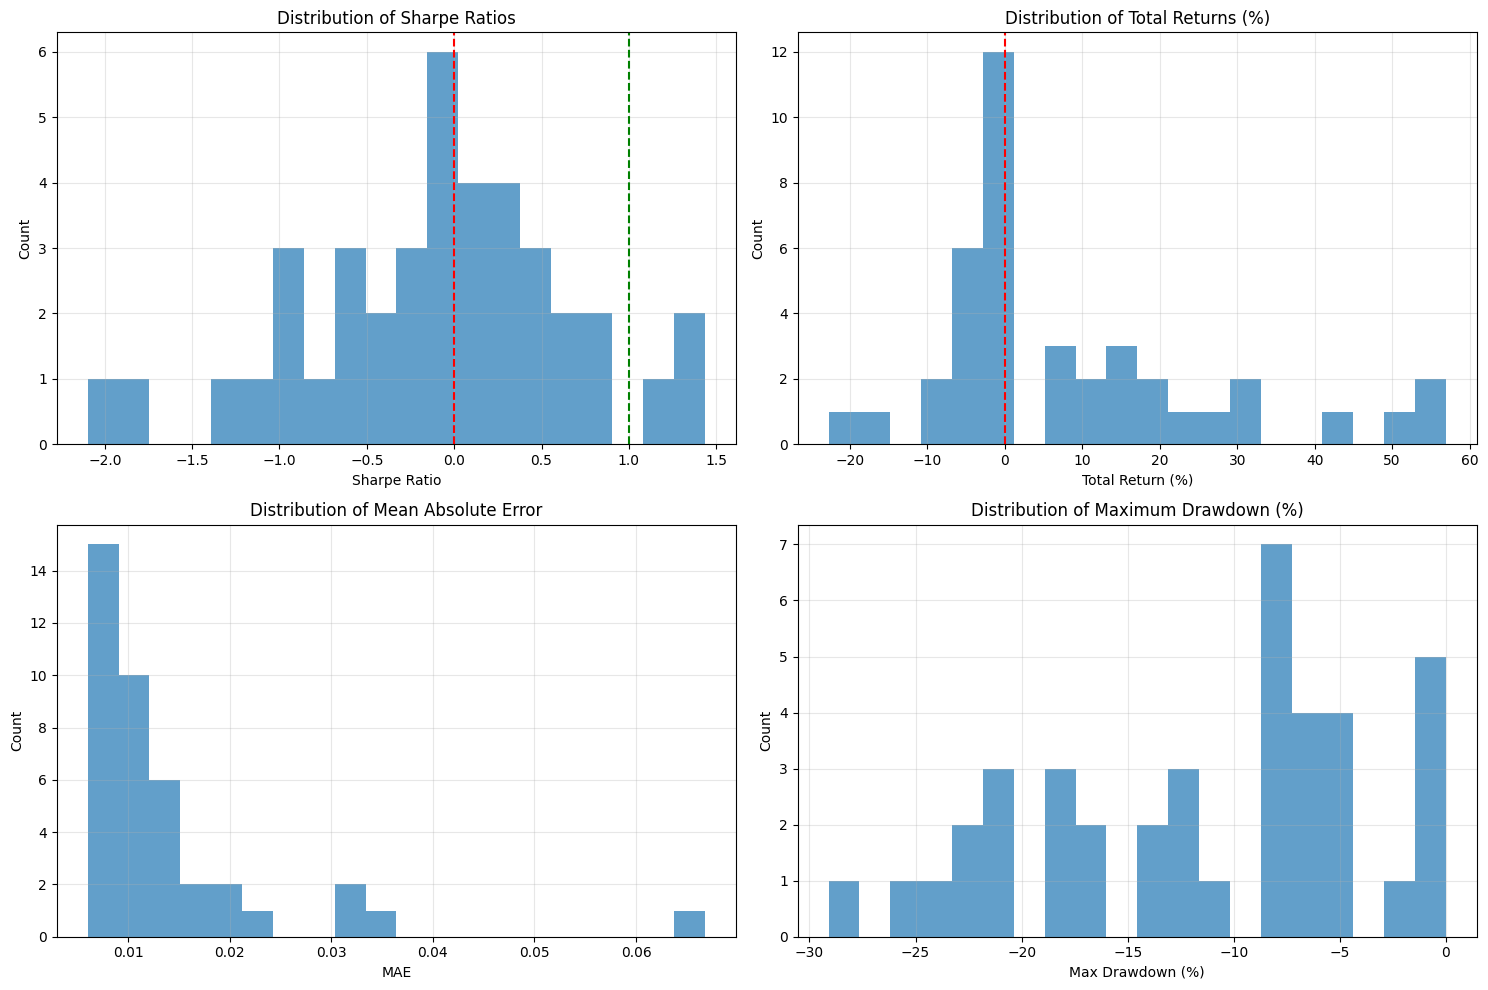

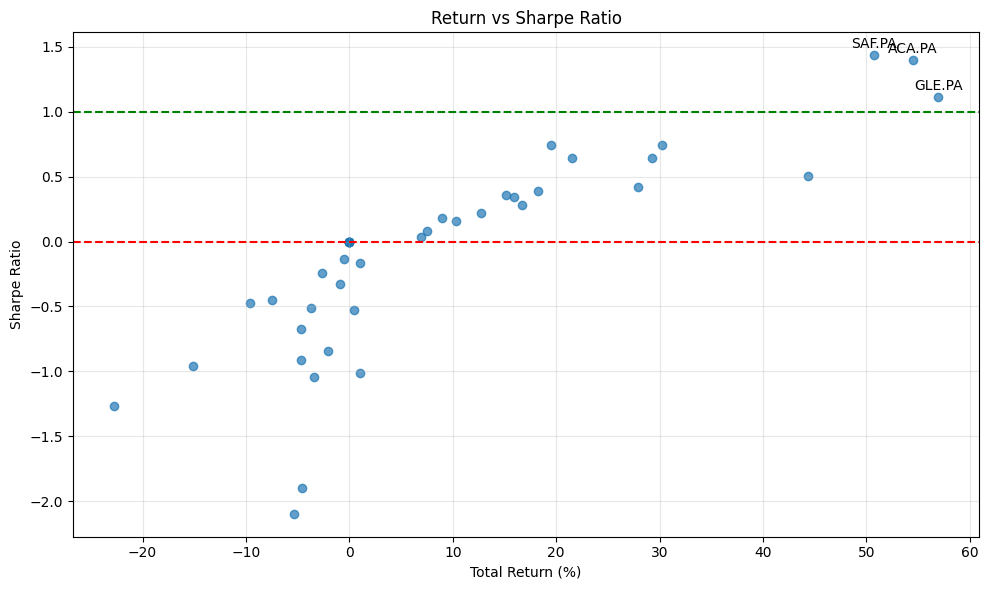

Selected 7 tickers out of 7 filtered tickers

Best tickers for portfolio:
     Ticker     Score    Weight    Sharpe  Total_Return       MAE  \
1    ACA.PA  0.883228  0.194416  1.400025     54.505141  0.009524   
29   SAF.PA  0.883040  0.194375  1.435892     50.725592  0.007487   
16   GLE.PA  0.753891  0.165946  1.113037     56.931230  0.019705   
14  ENGI.PA  0.542717  0.119463  0.641170     21.561191  0.007699   
24   ORA.PA  0.526196  0.115826  0.747240     19.471317  0.007507   
3    AIR.PA  0.508697  0.111974  0.646413     29.306902  0.008605   
35   TEP.PA  0.445211  0.098000  0.505411     44.321586  0.014308   

    Max_Drawdown  Num_Trades  Win_Rate  
1      -5.307663           3     100.0  
29     -5.596823           4     100.0  
16     -7.295663          16     100.0  
14     -7.486806           3     100.0  
24     -8.479461           8      75.0  
3     -14.490602           3     100.0  
35    -21.644855           2     100.0  


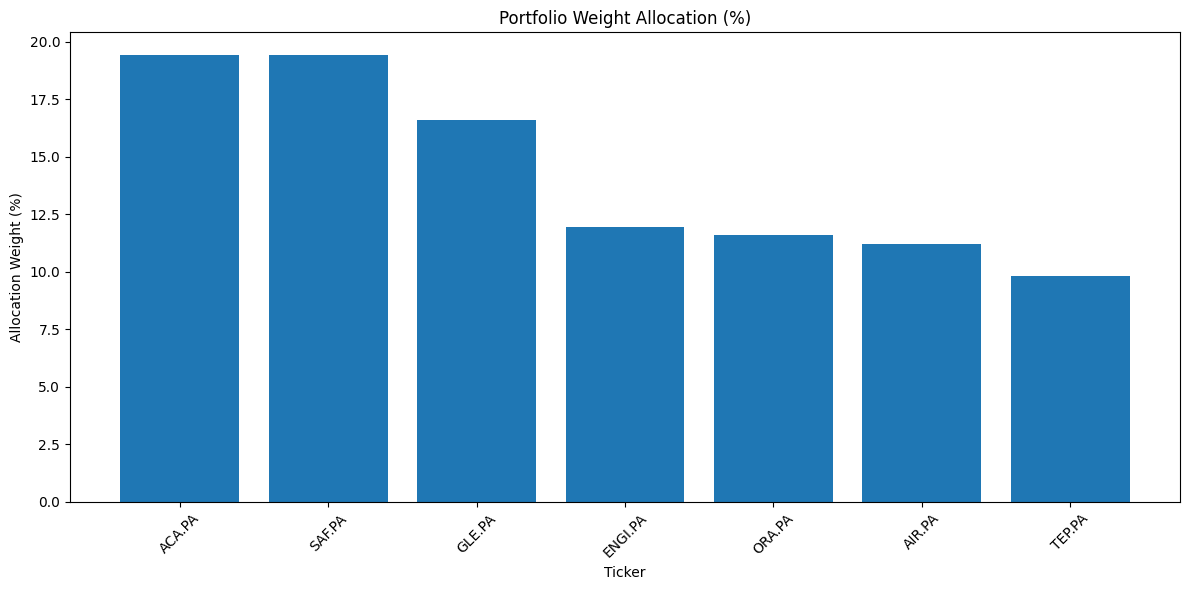

In [23]:
import pandas as pd

results_df = pd.read_csv("my_saved_results.csv")


# Analyze and visualize results
print("\nAnalyzing model performance...")
analysis = analyze_model_results(results_df, min_trades=2)  # Require at least 2 trades

# Visualize performance distributions
visualize_performance_distribution(results_df)

# Select best tickers for portfolio
best_tickers = select_best_tickers(
    results_df, 
    min_trades=2, 
    min_sharpe=0.5,  # Only consider tickers with positive Sharpe ratio > 0.5
    max_tickers=10   # Select top 10 tickers
)

# Display portfolio allocation
if best_tickers is not None:
    print("\nBest tickers for portfolio:")
    print(best_tickers)
    
    plt.figure(figsize=(12, 6))
    plt.bar(best_tickers['Ticker'], best_tickers['Weight'] * 100)
    plt.title('Portfolio Weight Allocation (%)')
    plt.ylabel('Allocation Weight (%)')
    plt.xlabel('Ticker')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [27]:
import numpy as np
import pandas as pd

def backtest_portfolio(selected_tickers, enhanced_df, initial_capital=100000, 
                      transaction_cost=0.001, rebalance_freq=20, risk_per_trade=0.02):
    """
    Backtest a portfolio of selected tickers using a rebalancing strategy
    with FIFO-based realized P&L tracking.

    Parameters:
    -----------
    selected_tickers : DataFrame
        DataFrame containing selected tickers and their weights
    enhanced_df : DataFrame
        DataFrame with all technical indicators for all tickers
    initial_capital : float
        Starting capital for the portfolio
    transaction_cost : float
        Transaction cost as a percentage (0.001 = 0.1%)
    rebalance_freq : int
        Frequency of portfolio rebalancing in trading days
    risk_per_trade : float
        Maximum risk per trade as percentage of portfolio (0.02 = 2%)

    Returns:
    --------
    dict : Portfolio performance metrics and time series (including FIFO-based P&L).
    """

    # Extract tickers and weights
    tickers = selected_tickers['Ticker'].tolist()
    weights = selected_tickers['Weight'].tolist()
    
    # Filter data for selected tickers
    portfolio_data = enhanced_df[enhanced_df['Ticker'].isin(tickers)].copy()
    
    # Get all unique dates across all tickers
    all_dates = sorted(portfolio_data['Datetime'].unique())
    
    # Create a dictionary to store price data for each ticker by date
    price_data = {}
    for ticker in tickers:
        ticker_df = portfolio_data[portfolio_data['Ticker'] == ticker].copy()
        price_data[ticker] = dict(zip(ticker_df['Datetime'], ticker_df['Close']))
    
    # Initialize portfolio tracking
    portfolio = {
        'cash': initial_capital,
        'positions': {ticker: 0 for ticker in tickers},
        'dates': [],
        'equity': [],
        'returns': [],
        'trades': [],
        'allocations': []
    }
    
    # Track performance
    daily_returns = []
    equity_curve = [initial_capital]
    drawdowns = [0]
    max_equity = initial_capital
    current_drawdown = 0
    
    # --------------------------------------------
    # ADDITION #1: Position ledger + realized P&L
    # --------------------------------------------
    position_ledger = {ticker: [] for ticker in tickers}  # FIFO lot tracking
    realized_pnl = []  # Detailed record of realized trades

    # Start backtesting
    print(f"Starting backtest with {len(all_dates)} trading days...")
    
    for i, date in enumerate(all_dates):
        portfolio['dates'].append(date)
        
        # Calculate current portfolio value
        portfolio_value = portfolio['cash']
        current_allocations = {}
        
        for ticker in tickers:
            if date in price_data[ticker]:
                price = price_data[ticker][date]
                position_value = portfolio['positions'][ticker] * price
                portfolio_value += position_value
                
                # Calculate allocation percentage
                if portfolio_value > 0:
                    allocation = position_value / portfolio_value
                    current_allocations[ticker] = allocation
                else:
                    current_allocations[ticker] = 0
        
        # Track equity and drawdown
        equity_curve.append(portfolio_value)
        if portfolio_value > max_equity:
            max_equity = portfolio_value
            current_drawdown = 0
        else:
            current_drawdown = (max_equity - portfolio_value) / max_equity
        drawdowns.append(current_drawdown)
        
        # Calculate daily return
        if i > 0:
            daily_ret = (portfolio_value / equity_curve[-2]) - 1
            daily_returns.append(daily_ret)
        else:
            daily_returns.append(0)
        
        # Store portfolio metrics
        portfolio['equity'].append(portfolio_value)
        if i > 0:
            portfolio['returns'].append((portfolio_value / portfolio['equity'][-2]) - 1)
        else:
            portfolio['returns'].append(0)
        
        portfolio['allocations'].append(current_allocations)
        
        # Check if we need to rebalance
        should_rebalance = (i % rebalance_freq == 0) and i > 0
        
        if should_rebalance:
            # Rebalance portfolio according to target weights
            target_values = {ticker: portfolio_value * weight for ticker, weight in zip(tickers, weights)}
            
            for ticker in tickers:
                if date in price_data[ticker]:
                    current_price = price_data[ticker][date]
                    current_value = portfolio['positions'][ticker] * current_price
                    target_value = target_values[ticker]
                    
                    # Calculate shares to buy/sell
                    value_difference = target_value - current_value
                    shares_to_adjust = int(value_difference / current_price) if current_price else 0
                    
                    # Apply risk management - limit position size
                    max_risk = portfolio_value * risk_per_trade
                    max_shares = int(max_risk / current_price) if current_price else 0
                    if abs(shares_to_adjust) > max_shares:
                        shares_to_adjust = max_shares if shares_to_adjust > 0 else -max_shares
                    
                    # Execute the trade if significant
                    if abs(shares_to_adjust) > 0:
                        cost = shares_to_adjust * current_price
                        transaction_fee = abs(cost) * transaction_cost
                        
                        # Check if we have enough cash for buying
                        if shares_to_adjust > 0 and (cost + transaction_fee) > portfolio['cash']:
                            # Adjust shares based on available cash
                            affordable_shares = int((portfolio['cash'] - transaction_fee) / current_price)
                            shares_to_adjust = max(0, affordable_shares)
                            cost = shares_to_adjust * current_price
                            transaction_fee = abs(cost) * transaction_cost
                        
                        # Execute the trade
                        if shares_to_adjust != 0:
                            portfolio['positions'][ticker] += shares_to_adjust
                            portfolio['cash'] -= (cost + transaction_fee)
                            
                            # Record the trade (high-level log)
                            portfolio['trades'].append({
                                'date': date,
                                'ticker': ticker,
                                'action': 'buy' if shares_to_adjust > 0 else 'sell',
                                'price': current_price,
                                'shares': abs(shares_to_adjust),
                                'value': abs(cost),
                                'fee': transaction_fee
                            })
                            
                            # -----------------------------------------------
                            # ADDITION #2: FIFO ledger for realized P&L
                            # -----------------------------------------------
                            if shares_to_adjust > 0:
                                # Buying -> add a new lot to the ledger
                                position_ledger[ticker].append({
                                    'date_in': date,
                                    'price_in': current_price,
                                    'shares': shares_to_adjust,
                                    'cost_basis': cost,  # current_price * shares_to_adjust
                                    'active': True
                                })
                            else:
                                # Selling -> implement FIFO logic
                                shares_to_sell = abs(shares_to_adjust)
                                trade_pnl = 0
                                
                                # Match sells against existing positions
                                while shares_to_sell > 0 and any(pos['active'] for pos in position_ledger[ticker]):
                                    # Find the oldest active lot
                                    oldest_pos = None
                                    for pos in position_ledger[ticker]:
                                        if pos['active']:
                                            oldest_pos = pos
                                            break
                                    
                                    if not oldest_pos:
                                        break  # no active lots left
                                    
                                    # Determine how many shares to close from this position
                                    shares_closed = min(shares_to_sell, oldest_pos['shares'])
                                    percentage_closed = shares_closed / oldest_pos['shares']
                                    
                                    # Calculate realized P&L for this portion
                                    cost_basis_portion = oldest_pos['cost_basis'] * percentage_closed
                                    sale_value = current_price * shares_closed
                                    position_pnl = sale_value - cost_basis_portion
                                    
                                    # Record the P&L
                                    realized_pnl.append({
                                        'date': date,
                                        'ticker': ticker,
                                        'shares': shares_closed,
                                        'entry_price': oldest_pos['price_in'],
                                        'exit_price': current_price,
                                        'pnl': position_pnl,
                                        'is_win': position_pnl > 0
                                    })
                                    
                                    # Update the oldest lot
                                    oldest_pos['shares'] -= shares_closed
                                    oldest_pos['cost_basis'] -= cost_basis_portion
                                    if oldest_pos['shares'] <= 0:
                                        oldest_pos['active'] = False
                                    
                                    shares_to_sell -= shares_closed
                                    trade_pnl += position_pnl
                            # -----------------------------------------------
                            # End of FIFO logic
                            # -----------------------------------------------

    # Calculate final performance metrics
    final_value = portfolio['equity'][-1]
    total_return = (final_value / initial_capital) - 1 if initial_capital else 0
    
    # Calculate annualized return
    if len(portfolio['dates']) > 1:
        days = (portfolio['dates'][-1] - portfolio['dates'][0]).days
    else:
        days = 1
    years = days / 365.25
    annualized_return = (1 + total_return) ** (1 / max(years, 0.01)) - 1 if years > 0 else total_return
    
    # Calculate Sharpe ratio (assuming risk-free rate of 0.02)
    risk_free_rate = 0.02
    daily_excess_returns = np.array(daily_returns) - (risk_free_rate / 252)
    if np.std(daily_excess_returns) > 0:
        sharpe_ratio = (np.mean(daily_excess_returns) / np.std(daily_excess_returns)) * np.sqrt(252)
    else:
        sharpe_ratio = 0
    
    # Calculate max drawdown
    max_drawdown = max(drawdowns) if drawdowns else 0
    
    # ---------------------------------
    # Existing "Improved Win Rate" logic
    # ---------------------------------
    trades_df = pd.DataFrame(portfolio['trades']) if portfolio['trades'] else pd.DataFrame()
    if len(trades_df) > 0:
        trades_analysis = trades_df.copy()
        trades_analysis.sort_values(['ticker', 'date'], inplace=True)
        trades_analysis['rebalance_group'] = (trades_analysis['date'] != trades_analysis['date'].shift()).cumsum()
        
        rebalance_results = []
        for (ticker, rebalance_id), group in trades_analysis.groupby(['ticker', 'rebalance_group']):
            if not (group['action'] == 'buy').any() or not (group['action'] == 'sell').any():
                continue
            buys = group[group['action'] == 'buy']
            sells = group[group['action'] == 'sell']
            
            buy_value = (buys['price'] * buys['shares']).sum()
            sell_value = (sells['price'] * sells['shares']).sum()
            buy_shares = buys['shares'].sum()
            sell_shares = sells['shares'].sum()
            
            realized_shares = min(buy_shares, sell_shares)
            if realized_shares > 0:
                avg_buy_price = buy_value / buy_shares
                avg_sell_price = sell_value / sell_shares
                pnl = (avg_sell_price - avg_buy_price) * realized_shares
                
                rebalance_results.append({
                    'ticker': ticker,
                    'rebalance_id': rebalance_id,
                    'date': group['date'].iloc[0],
                    'pnl': pnl,
                    'is_win': pnl > 0
                })
        
        if rebalance_results:
            rebalance_df = pd.DataFrame(rebalance_results)
            win_count = rebalance_df['is_win'].sum()
            total_events = len(rebalance_df)
            win_rate = win_count / total_events
            
            print(f"Analyzed {total_events} rebalancing events")
            print(f"Winning trades: {win_count} ({win_rate:.2%})")
            print(f"Total PnL: ${rebalance_df['pnl'].sum():.2f}")
            metrics_win_rate = win_rate
        else:
            metrics_win_rate = 0
    else:
        metrics_win_rate = 0
    
    # Compile all metrics
    # You can also compute total realized PnL from the new FIFO ledger here.
    total_realized_pnl = sum(item['pnl'] for item in realized_pnl)
    
    metrics = {
        'initial_capital': initial_capital,
        'final_value': final_value,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': metrics_win_rate,
        'trades_count': len(portfolio['trades']),
        'dates': portfolio['dates'],
        'equity_curve': portfolio['equity'],
        'returns': portfolio['returns'],
        'drawdowns': drawdowns,
        'trades': portfolio['trades'],
        'allocations': portfolio['allocations'],
        
        # FIFO-based P&L details
        'position_ledger': position_ledger,
        'realized_pnl': realized_pnl,
        'total_realized_pnl': total_realized_pnl,
    }
    
    # Print a summary of results
    print(f"\nPortfolio Backtest Results:")
    print(f"Initial Capital: ${initial_capital:,.2f}")
    print(f"Final Value: ${final_value:,.2f}")
    print(f"Total Return: {total_return:.2%}")
    print(f"Annualized Return: {annualized_return:.2%}")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown: {max_drawdown:.2%}")
    print(f"Win Rate (Rebalance-based): {metrics_win_rate:.2%}")
    print(f"Number of Trades: {len(portfolio['trades'])}")
    print(f"Total Realized PnL (FIFO): ${total_realized_pnl:,.2f}")
    
    return metrics


def visualize_portfolio_performance(metrics):
    """
    Create a comprehensive visualization dashboard for portfolio performance.
    
    Parameters:
    -----------
    metrics : dict
        Dictionary of portfolio performance metrics from backtest_portfolio
    """
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 14))
    
    # 1. Equity Curve
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(metrics['dates'], metrics['equity_curve'])
    ax1.set_title('Portfolio Equity Curve')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.grid(True)
    
    # 2. Drawdowns - Fix the length mismatch
    ax2 = plt.subplot(3, 2, 2)
    # Ensure drawdowns and dates have the same length
    if len(metrics['dates']) != len(metrics['drawdowns']):
        # Use the minimum length to avoid index errors
        min_length = min(len(metrics['dates']), len(metrics['drawdowns']))
        plot_dates = metrics['dates'][:min_length]
        plot_drawdowns = metrics['drawdowns'][:min_length]
    else:
        plot_dates = metrics['dates']
        plot_drawdowns = metrics['drawdowns']
        
    ax2.fill_between(plot_dates, [0] * len(plot_drawdowns), 
                     [-d for d in plot_drawdowns], color='red', alpha=0.3)
    ax2.set_title('Portfolio Drawdowns')
    ax2.set_ylabel('Drawdown (%)')
    ax2.grid(True)
    
    # 3. Daily Returns Distribution
    ax3 = plt.subplot(3, 2, 3)
    returns = np.array(metrics['returns'][1:])  # Skip first element (0)
    sns.histplot(returns, kde=True, ax=ax3)
    ax3.set_title('Daily Returns Distribution')
    ax3.set_xlabel('Return')
    ax3.set_ylabel('Frequency')
    
    # 4. Cumulative Returns
    ax4 = plt.subplot(3, 2, 4)
    cumulative_returns = [(val/metrics['equity_curve'][0]) - 1 for val in metrics['equity_curve']]
    ax4.plot(metrics['dates'], cumulative_returns)
    ax4.set_title('Cumulative Returns')
    ax4.set_ylabel('Return (%)')
    ax4.grid(True)
    
    # 5. Monthly Returns Heatmap
    ax5 = plt.subplot(3, 2, 5)
    
    # Create DataFrame with dates and returns
    returns_df = pd.DataFrame({
        'date': metrics['dates'],
        'return': metrics['returns']
    })
    
    # Ensure lengths match
    if len(returns_df) > len(metrics['returns']):
        returns_df = returns_df.iloc[:len(metrics['returns'])]
    
    returns_df.set_index('date', inplace=True)
    
    try:
        # Aggregate returns by month and year
        monthly_returns = returns_df.resample('M')['return'].apply(
            lambda x: (1 + x).prod() - 1
        )
        
        # Create a pivot table for the heatmap
        if len(monthly_returns) > 0:
            monthly_pivot = pd.DataFrame({
                'Year': monthly_returns.index.year,
                'Month': monthly_returns.index.month,
                'Return': monthly_returns.values
            })
            
            heatmap_data = monthly_pivot.pivot_table(
                index='Year', columns='Month', values='Return'
            )
            
            sns.heatmap(heatmap_data, cmap='RdYlGn', ax=ax5, 
                        annot=True, fmt=".1%", center=0)
            ax5.set_title('Monthly Returns Heatmap')
        else:
            ax5.text(0.5, 0.5, 'Insufficient data for monthly heatmap', 
                     horizontalalignment='center', verticalalignment='center')
    except Exception as e:
        ax5.text(0.5, 0.5, f'Error creating heatmap: {str(e)}', 
                 horizontalalignment='center', verticalalignment='center')
    
    # 6. Trade Analysis
    ax6 = plt.subplot(3, 2, 6)
    
    if metrics['trades_count'] > 0:
        # Create DataFrame for trades
        trades_df = pd.DataFrame(metrics['trades'])
        
        # Group trades by ticker
        trade_counts = trades_df.groupby('ticker').size()
        trade_values = trades_df.groupby('ticker')['value'].sum()
        
        # Create a combined metric
        combined_data = pd.DataFrame({
            'count': trade_counts,
            'value': trade_values
        })
        
        # Plot pie chart
        ax6.pie(combined_data['count'], labels=combined_data.index, 
                autopct='%1.1f%%', startangle=90)
        ax6.axis('equal')
        ax6.set_title('Trade Distribution by Ticker')
    else:
        ax6.text(0.5, 0.5, 'No trades executed during backtest', 
                 horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    # Additional visualization: Asset Allocation Over Time
    if metrics['allocations']:
        try:
            # Convert allocations to DataFrame for easier plotting
            allocations_list = []
            for i, alloc in enumerate(metrics['allocations']):
                if i < len(metrics['dates']):  # Ensure we don't exceed dates length
                    alloc_data = {'Date': metrics['dates'][i]}
                    alloc_data.update(alloc)
                    allocations_list.append(alloc_data)
                
            if allocations_list:
                allocations_df = pd.DataFrame(allocations_list)
                allocations_df.set_index('Date', inplace=True)
                
                # Plot stacked area chart
                plt.figure(figsize=(14, 6))
                
                # Convert to numeric columns
                for col in allocations_df.columns:
                    allocations_df[col] = pd.to_numeric(allocations_df[col], errors='coerce').fillna(0)
                
                allocations_df.plot.area(figsize=(14, 6), alpha=0.7)
                plt.title('Portfolio Allocation Over Time')
                plt.ylabel('Allocation Ratio')
                plt.xlabel('Date')
                plt.grid(True)
                plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"Error creating allocation chart: {e}")


In [30]:
def analyze_pnl_details(metrics):
    """
    Analyze and visualize detailed P&L information from backtest results.
    
    Parameters:
    -----------
    metrics : dict
        Portfolio performance metrics from backtest_portfolio
    """
    if not metrics['realized_pnl']:
        print("No realized P&L data available to analyze.")
        return None, None
    
    # Convert realized P&L to DataFrame for analysis
    pnl_df = pd.DataFrame(metrics['realized_pnl'])
    
    # Check if entry_date exists, if not we can't calculate holding days
    if 'entry_date' in pnl_df.columns:
        # Add holding period
        pnl_df['holding_days'] = (pnl_df['date'] - pnl_df['entry_date']).dt.days
    else:
        print("Warning: entry_date field missing, cannot calculate holding period")
        pnl_df['holding_days'] = np.nan
    
    # Calculate return percentage
    pnl_df['return_pct'] = ((pnl_df['exit_price'] - pnl_df['entry_price']) / 
                           pnl_df['entry_price']) * 100
    
    # Summary statistics
    print("\nP&L Summary Statistics:")
    print(f"Average P&L: ${pnl_df['pnl'].mean():.2f}")
    print(f"Median P&L: ${pnl_df['pnl'].median():.2f}")
    print(f"Average Return: {pnl_df['return_pct'].mean():.2f}%")
    
    if not pnl_df['holding_days'].isna().all():
        print(f"Average Holding Period: {pnl_df['holding_days'].mean():.1f} days")
    
    # P&L by ticker
    agg_dict = {
        'pnl': ['sum', 'mean', 'count'],
        'is_win': 'mean',
        'return_pct': 'mean',
    }
    
    # Only include holding_days if available
    if not pnl_df['holding_days'].isna().all():
        agg_dict['holding_days'] = 'mean'
        
    ticker_summary = pnl_df.groupby('ticker').agg(agg_dict)
    
    # Fix column names
    column_names = ['Total_PnL', 'Avg_PnL', 'Trade_Count', 'Win_Rate', 'Avg_Return_Pct']
    if 'holding_days' in agg_dict:
        column_names.append('Avg_Holding_Days')
    
    ticker_summary.columns = column_names
    
    print("\nP&L by Ticker:")
    print(ticker_summary)
    
    # Create visualizations
    plt.figure(figsize=(14, 10))
    
    # 1. P&L Distribution
    plt.subplot(2, 2, 1)
    sns.histplot(pnl_df['pnl'], kde=True)
    plt.axvline(0, color='red', linestyle='--')
    plt.title('P&L Distribution')
    plt.xlabel('P&L ($)')
    
    # 2. P&L by Ticker
    plt.subplot(2, 2, 2)
    ticker_totals = pnl_df.groupby('ticker')['pnl'].sum().sort_values()
    ticker_totals.plot(kind='barh')
    plt.title('Total P&L by Ticker')
    plt.xlabel('P&L ($)')
    
    # 3. Win Rate by Ticker
    plt.subplot(2, 2, 3)
    win_rates = pnl_df.groupby('ticker')['is_win'].mean().sort_values()
    win_rates.plot(kind='barh')
    plt.title('Win Rate by Ticker')
    plt.xlabel('Win Rate')
    
    # 4. P&L Over Time
    plt.subplot(2, 2, 4)
    time_pnl = pnl_df.set_index('date')['pnl'].resample('M').sum().cumsum()
    time_pnl.plot()
    plt.title('Cumulative P&L Over Time')
    plt.xlabel('Date')
    plt.ylabel('Cumulative P&L ($)')
    
    plt.tight_layout()
    plt.show()
    
    # Only show holding period plot if we have the data
    if not pnl_df['holding_days'].isna().all():
        plt.figure(figsize=(10, 6))
        plt.scatter(pnl_df['holding_days'], pnl_df['return_pct'], 
                    c=pnl_df['is_win'].map({True: 'green', False: 'red'}),
                    alpha=0.6)
        plt.axhline(0, color='black', linestyle='--')
        plt.title('Return vs. Holding Period')
        plt.xlabel('Holding Period (days)')
        plt.ylabel('Return (%)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return pnl_df, ticker_summary

Starting backtest with 4371 trading days...

Portfolio Backtest Results:
Initial Capital: $100,000.00
Final Value: $134,864.23
Total Return: 34.86%
Annualized Return: 17.00%
Sharpe Ratio: -0.03
Maximum Drawdown: 15.60%
Win Rate (Rebalance-based): 0.00%
Number of Trades: 1087
Total Realized PnL (FIFO): $3,498.44


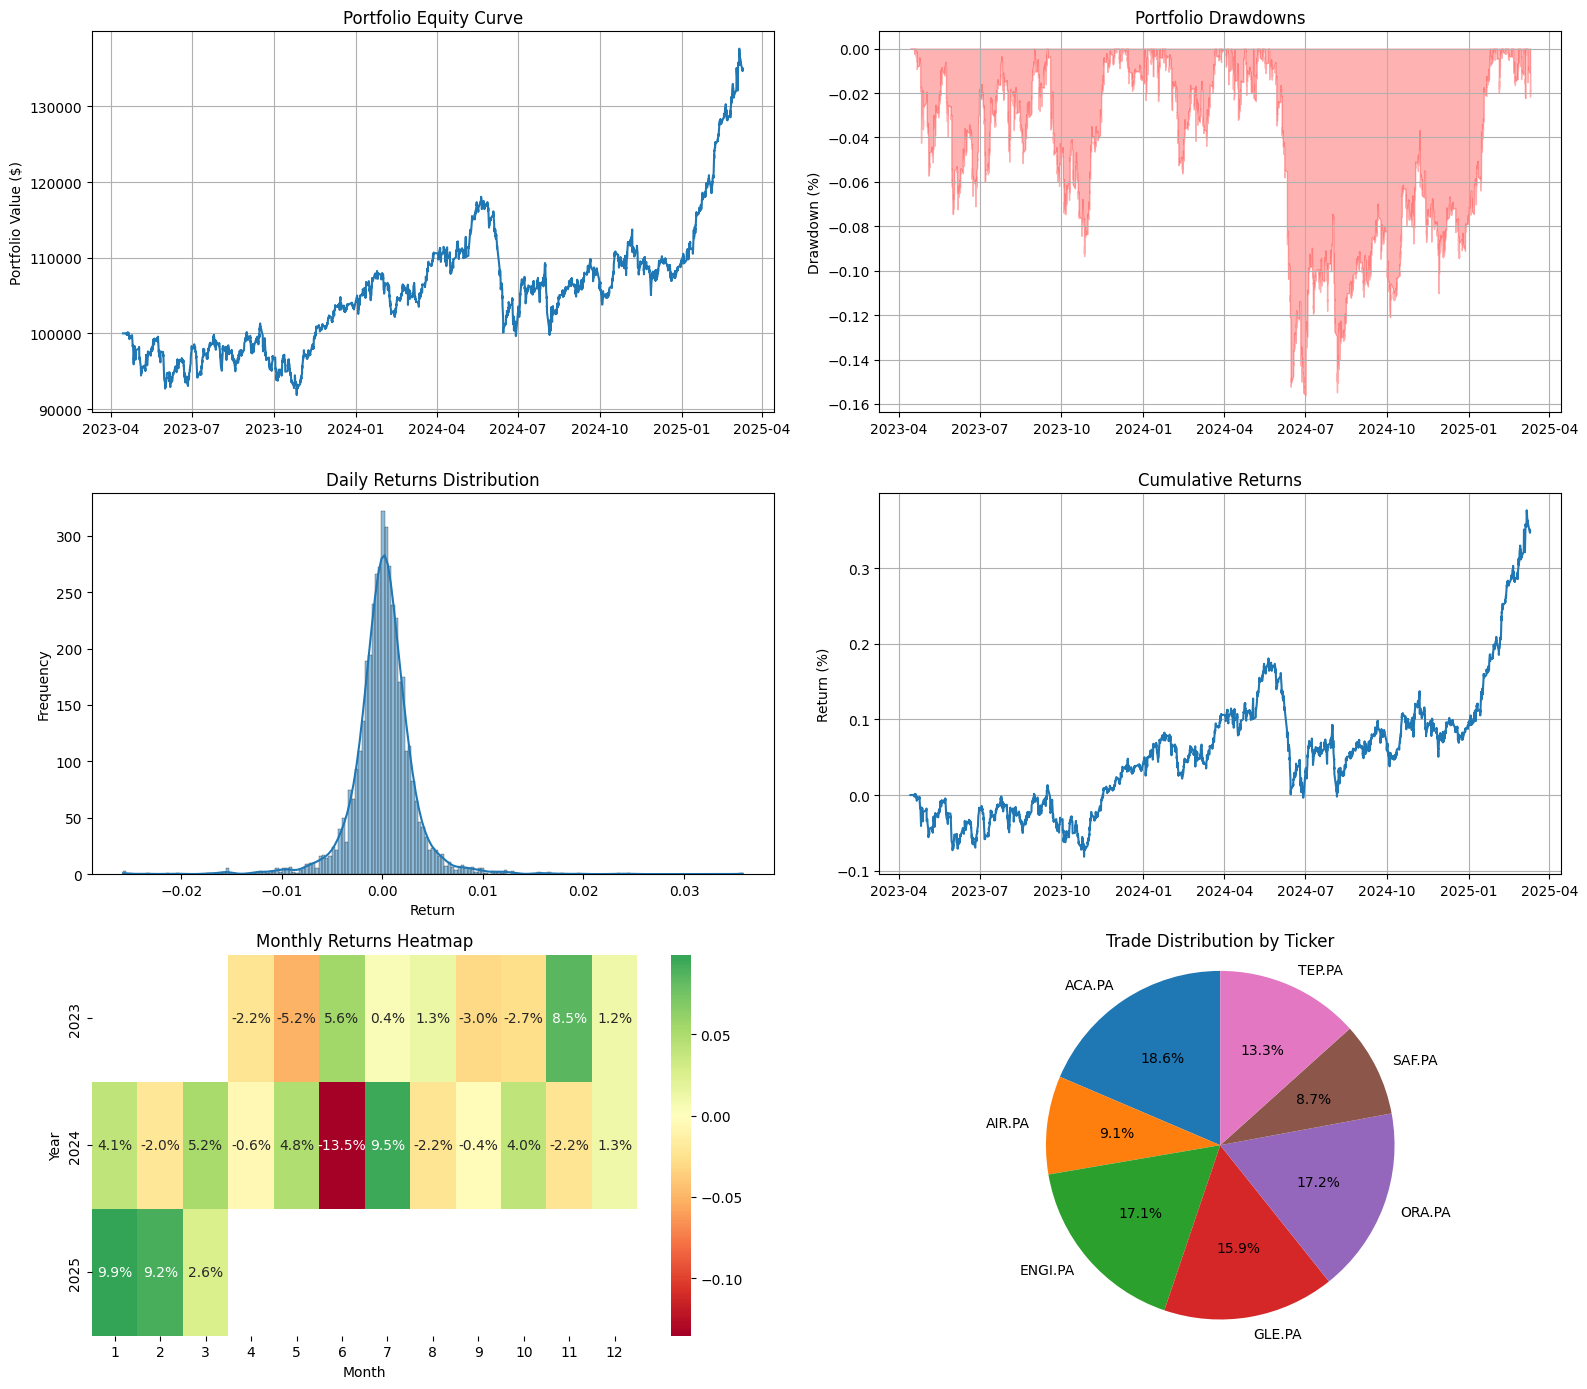

<Figure size 1400x600 with 0 Axes>

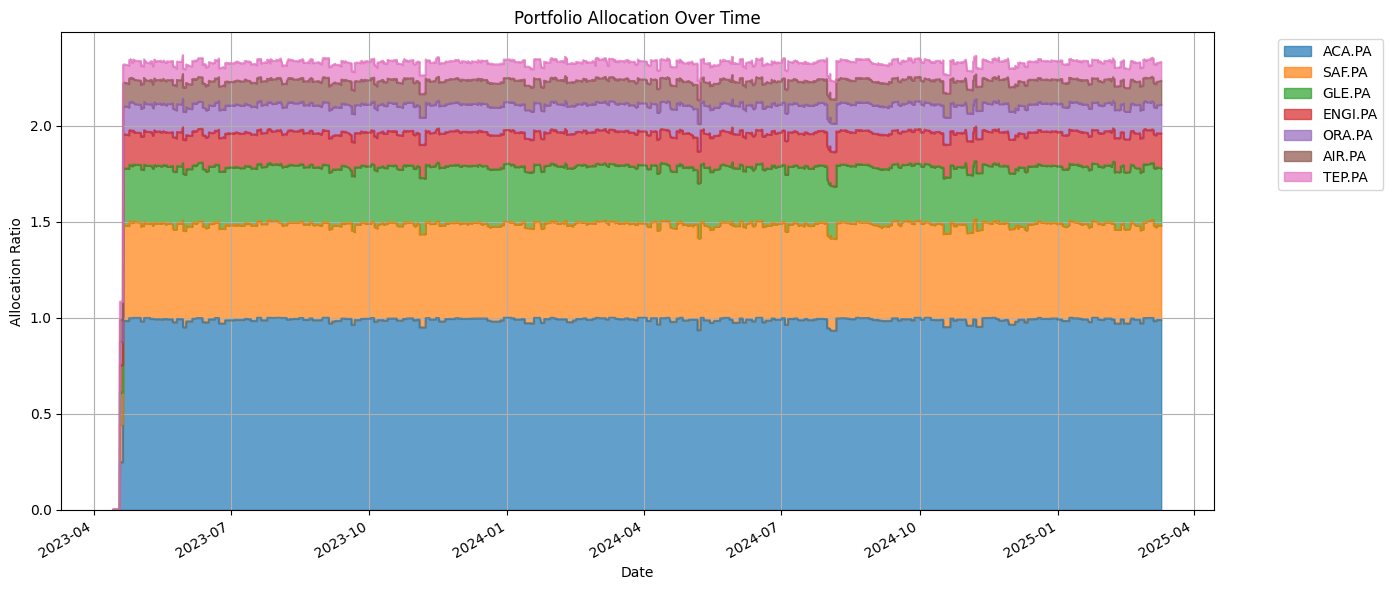


P&L Summary Statistics:
Average P&L: $5.98
Median P&L: $2.27
Average Return: 5.35%

P&L by Ticker:
           Total_PnL    Avg_PnL  Trade_Count  Win_Rate  Avg_Return_Pct
ticker                                                                
ACA.PA   2618.108016  26.715388           98  0.938776       18.590214
AIR.PA   1153.460220  23.069204           50  0.880000       11.941744
ENGI.PA   -19.452244  -0.213761           91  0.505495        0.959977
GLE.PA   3286.145302  29.340583          112  0.830357       15.572198
ORA.PA   -881.502878  -8.994927           98  0.091837       -7.299421
SAF.PA   3745.019699  73.431759           51  0.901961       29.059084
TEP.PA  -6403.339622 -75.333407           85  0.070588      -22.222858


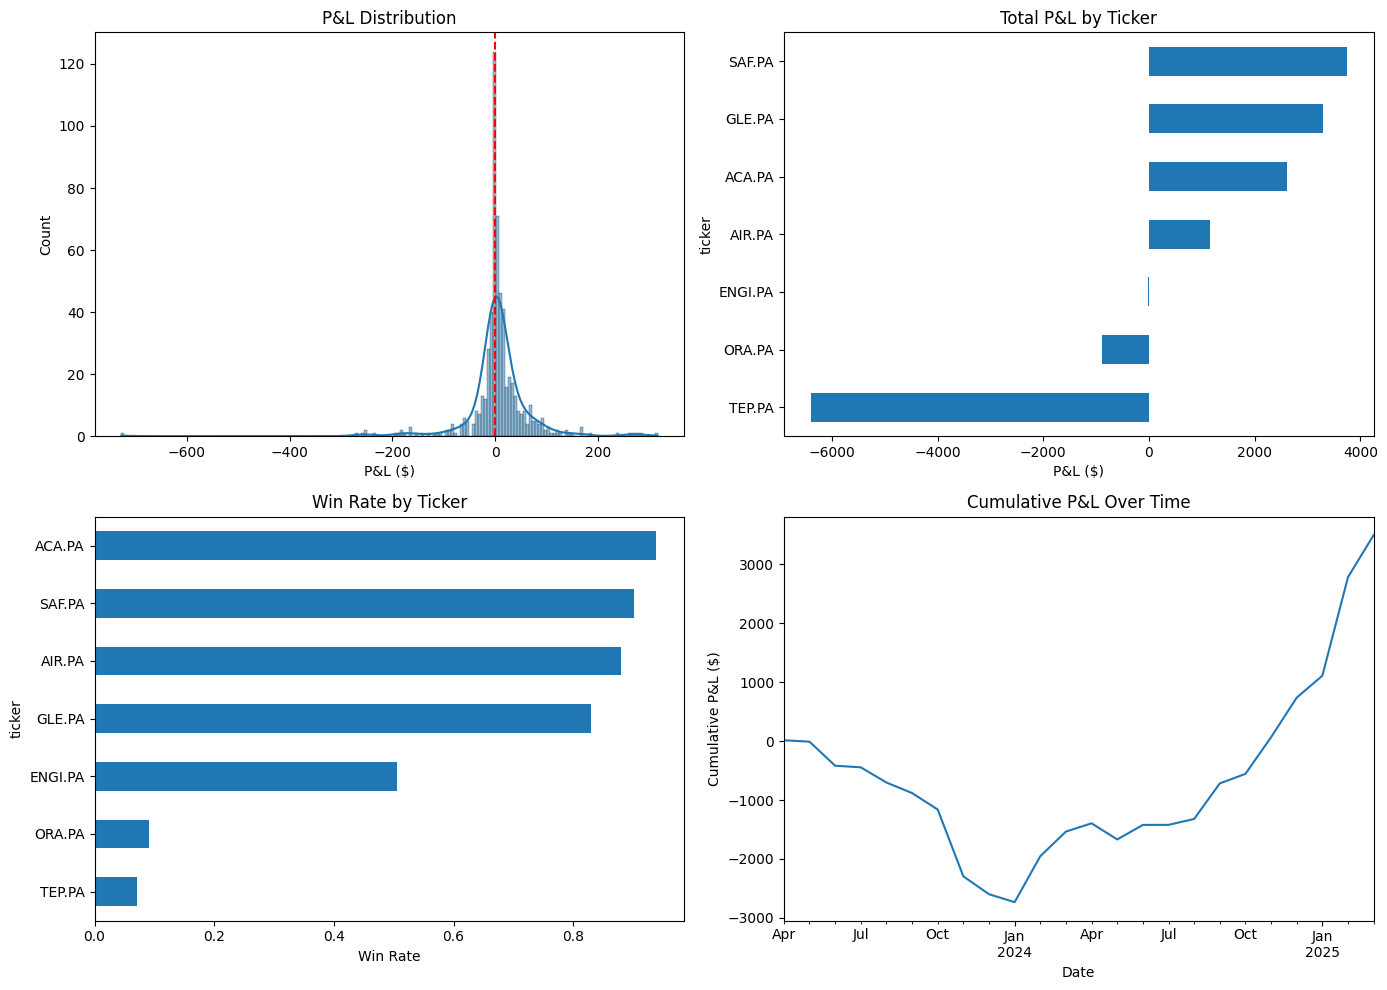

In [31]:
# Run the backtest on your selected portfolio
portfolio_metrics = backtest_portfolio(
    best_tickers,  # From your selection function
    enhanced_df,   # Your data with technical indicators
    initial_capital=100000,
    transaction_cost=0.001,  # 0.1% transaction cost
    rebalance_freq=20,       # Rebalance every 20 trading days
    risk_per_trade=0.1      # % risk per trade
)

# Visualize the results
visualize_portfolio_performance(portfolio_metrics)

# Analyze detailed P&L
pnl_df, ticker_summary = analyze_pnl_details(portfolio_metrics)

In [33]:
def analyze_trade_performance(portfolio_metrics):
    """
    Analyze individual trade performance to identify patterns
    """
    if not portfolio_metrics['trades']:
        print("No trades to analyze")
        return
        
    trades_df = pd.DataFrame(portfolio_metrics['trades'])
    
    # Sort by date
    trades_df.sort_values(['ticker', 'date'], inplace=True)
    
    # Group trades by rebalancing event
    trades_df['rebalance_date'] = trades_df['date'].dt.floor('D')
    
    # Calculate VWAP for buys and sells per ticker and rebalancing date
    buys = trades_df[trades_df['action'] == 'buy'].groupby(['ticker', 'rebalance_date']).apply(
        lambda x: pd.Series({
            'buy_vwap': (x['price'] * x['shares']).sum() / x['shares'].sum(),
            'buy_shares': x['shares'].sum(),
            'buy_value': x['value'].sum()
        })
    ).reset_index()
    
    sells = trades_df[trades_df['action'] == 'sell'].groupby(['ticker', 'rebalance_date']).apply(
        lambda x: pd.Series({
            'sell_vwap': (x['price'] * x['shares']).sum() / x['shares'].sum(),
            'sell_shares': x['shares'].sum(),
            'sell_value': x['value'].sum()
        })
    ).reset_index()
    
    # Merge buys and sells
    merged = pd.merge(buys, sells, on=['ticker', 'rebalance_date'], how='outer').fillna(0)
    
    # Calculate P&L
    merged['realized_shares'] = merged.apply(
        lambda row: min(row['buy_shares'], row['sell_shares']), axis=1
    )
    merged['pnl'] = merged.apply(
        lambda row: (row['sell_vwap'] - row['buy_vwap']) * row['realized_shares'] 
                    if row['realized_shares'] > 0 else 0, 
        axis=1
    )
    merged['is_win'] = merged['pnl'] > 0
    
    # Summary
    win_rate = merged[merged['pnl'] != 0]['is_win'].mean()
    total_pnl = merged['pnl'].sum()
    
    print(f"Trade-by-Trade Analysis:")
    print(f"Total Rebalancing Events: {len(merged)}")
    print(f"Events with P&L: {len(merged[merged['pnl'] != 0])}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total P&L: ${total_pnl:.2f}")
    
    # Show top winners and losers
    print("\nTop 5 Winning Trades:")
    print(merged.sort_values('pnl', ascending=False).head(5)[
        ['ticker', 'rebalance_date', 'pnl', 'buy_vwap', 'sell_vwap', 'realized_shares']
    ])
    
    print("\nTop 5 Losing Trades:")
    print(merged.sort_values('pnl').head(5)[
        ['ticker', 'rebalance_date', 'pnl', 'buy_vwap', 'sell_vwap', 'realized_shares']
    ])
    
    return merged

# Call this after running your backtest
trade_analysis = analyze_trade_performance(portfolio_metrics)

Trade-by-Trade Analysis:
Total Rebalancing Events: 1087
Events with P&L: 0
Win Rate: nan%
Total P&L: $0.00

Top 5 Winning Trades:
     ticker            rebalance_date  pnl  buy_vwap  sell_vwap  \
0    ACA.PA 2023-04-18 00:00:00+00:00    0    10.950      0.000   
730  ORA.PA 2023-12-20 00:00:00+00:00    0    10.464      0.000   
716  ORA.PA 2023-11-03 00:00:00+00:00    0    11.142      0.000   
717  ORA.PA 2023-11-07 00:00:00+00:00    0    11.006      0.000   
718  ORA.PA 2023-11-10 00:00:00+00:00    0     0.000     11.122   

     realized_shares  
0                0.0  
730              0.0  
716              0.0  
717              0.0  
718              0.0  

Top 5 Losing Trades:
     ticker            rebalance_date  pnl  buy_vwap  sell_vwap  \
0    ACA.PA 2023-04-18 00:00:00+00:00    0    10.950      0.000   
715  ORA.PA 2023-11-01 00:00:00+00:00    0     0.000     11.170   
716  ORA.PA 2023-11-03 00:00:00+00:00    0    11.142      0.000   
717  ORA.PA 2023-11-07 00:00:00+00:00  

In [35]:
# Instead of using df.append(...) (which was removed in newer Pandas versions),
# you can insert a new row by using loc with the current length of the DataFrame.

# Create a dataframe of ticker performance from your backtest results
ticker_performance = pd.DataFrame({
    'Ticker': [],
    'Win_Rate': [],
    'Avg_Return': [],
    'Total_PnL': []
})

# Populate it from your pnl_df analysis
for ticker, data in ticker_summary.iterrows():
    ticker_performance.loc[len(ticker_performance)] = {
        'Ticker': ticker,
        'Win_Rate': data['Win_Rate'],
        'Avg_Return': data['Avg_Return_Pct'],
        'Total_PnL': data['Total_PnL']
    }

def performance_weighted_allocation(ticker_summary):
    """
    Create optimized weights based on historical performance
    """
    if isinstance(ticker_summary, pd.DataFrame) and ticker_summary.index.name == 'ticker':
        ticker_data = ticker_summary.reset_index()
    else:
        ticker_data = ticker_summary.copy()
    
    result = pd.DataFrame()
    result['Ticker'] = ticker_data['ticker'] if 'ticker' in ticker_data.columns else ticker_data.index
    result['Win_Rate'] = ticker_data['Win_Rate']
    result['Avg_Return_Pct'] = ticker_data['Avg_Return_Pct']
    result['Total_PnL'] = ticker_data['Total_PnL']
    
    # A simple composite score
    result['Score'] = result['Win_Rate'] * result['Total_PnL']
    
    # Minimum allocation for diversification
    min_weight = 0.03
    result['Initial_Weight'] = np.where(result['Score'] > 0, result['Score'], min_weight)
    
    # Normalize weights to sum to 1
    result['Weight'] = result['Initial_Weight'] / result['Initial_Weight'].sum()
    result['Weight'] = result['Weight'].round(4)
    
    return result

# Generate optimized weights
optimized_weights = performance_weighted_allocation(ticker_summary)
print("Optimized Portfolio Weights:")
print(optimized_weights[['Ticker', 'Weight', 'Win_Rate', 'Avg_Return_Pct', 'Total_PnL']])


Optimized Portfolio Weights:
    Ticker  Weight  Win_Rate  Avg_Return_Pct    Total_PnL
0   ACA.PA  0.2566  0.938776       18.590214  2618.108016
1   AIR.PA  0.1060  0.880000       11.941744  1153.460220
2  ENGI.PA  0.0000  0.505495        0.959977   -19.452244
3   GLE.PA  0.2848  0.830357       15.572198  3286.145302
4   ORA.PA  0.0000  0.091837       -7.299421  -881.502878
5   SAF.PA  0.3526  0.901961       29.059084  3745.019699
6   TEP.PA  0.0000  0.070588      -22.222858 -6403.339622


Starting backtest with 4371 trading days...

Portfolio Backtest Results:
Initial Capital: $100,000.00
Final Value: $168,513.13
Total Return: 68.51%
Annualized Return: 31.50%
Sharpe Ratio: 0.20
Maximum Drawdown: 20.23%
Win Rate (Rebalance-based): 0.00%
Number of Trades: 623
Total Realized PnL (FIFO): $19,445.46


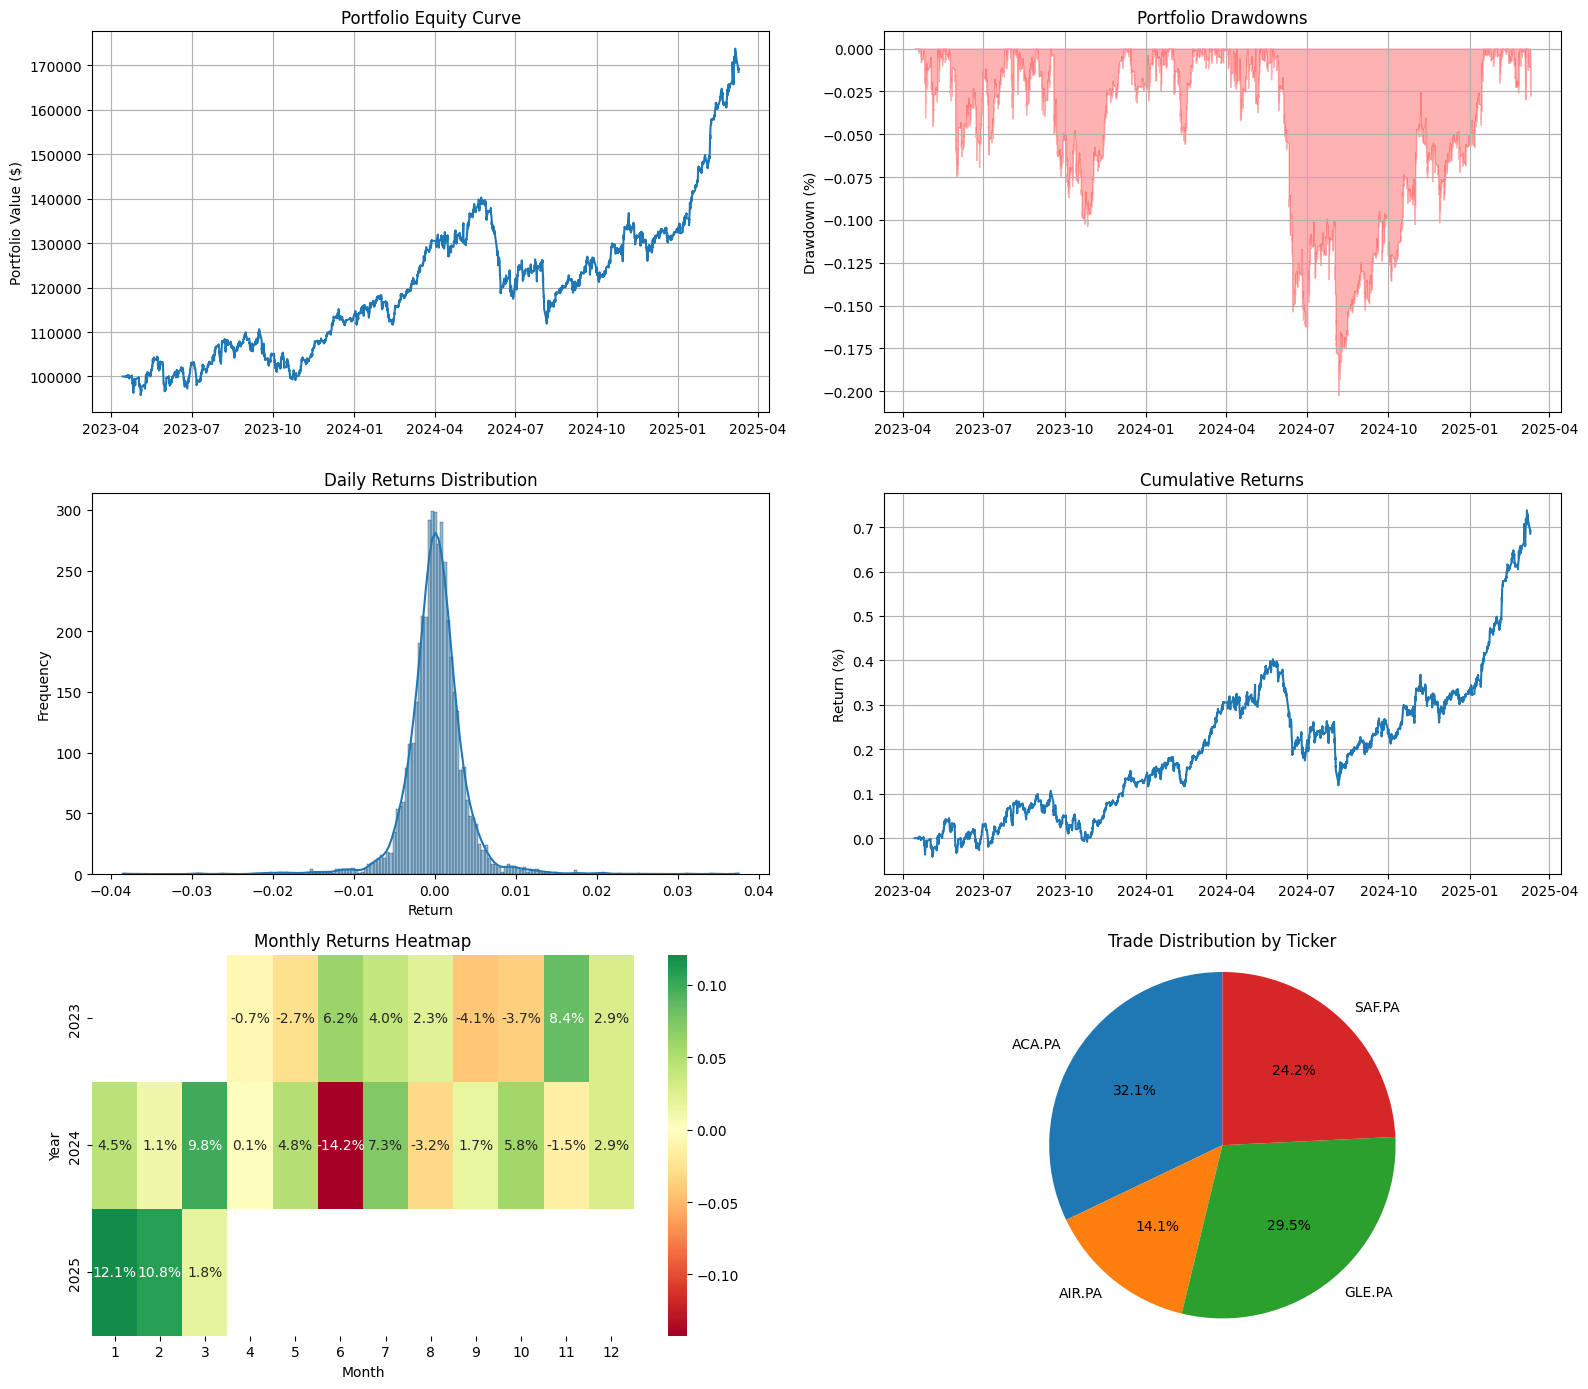

<Figure size 1400x600 with 0 Axes>

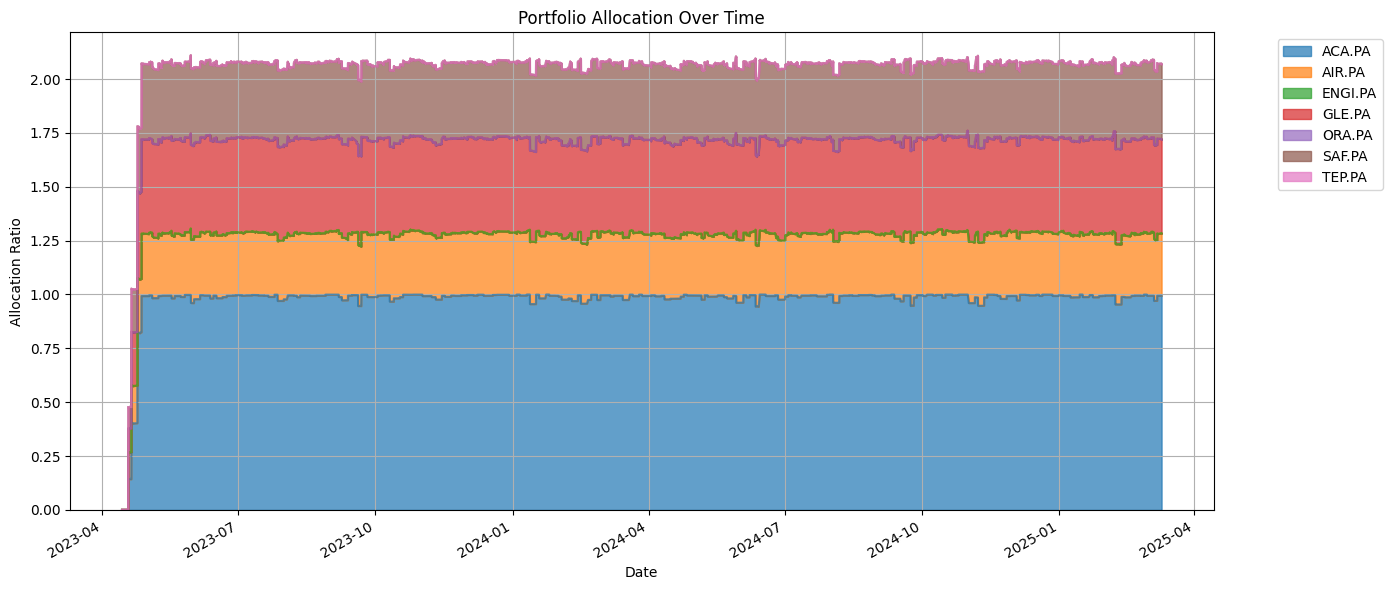


P&L Summary Statistics:
Average P&L: $66.82
Median P&L: $28.96
Average Return: 21.75%

P&L by Ticker:
          Total_PnL     Avg_PnL  Trade_Count  Win_Rate  Avg_Return_Pct
ticker                                                                
ACA.PA  3570.622982   44.081765           81  0.950617       19.069337
AIR.PA   988.180176   26.707572           37  0.891892       12.476012
GLE.PA  5711.355127   57.690456           99  0.878788       20.160690
SAF.PA  9175.299683  123.990536           74  0.905405       31.434172


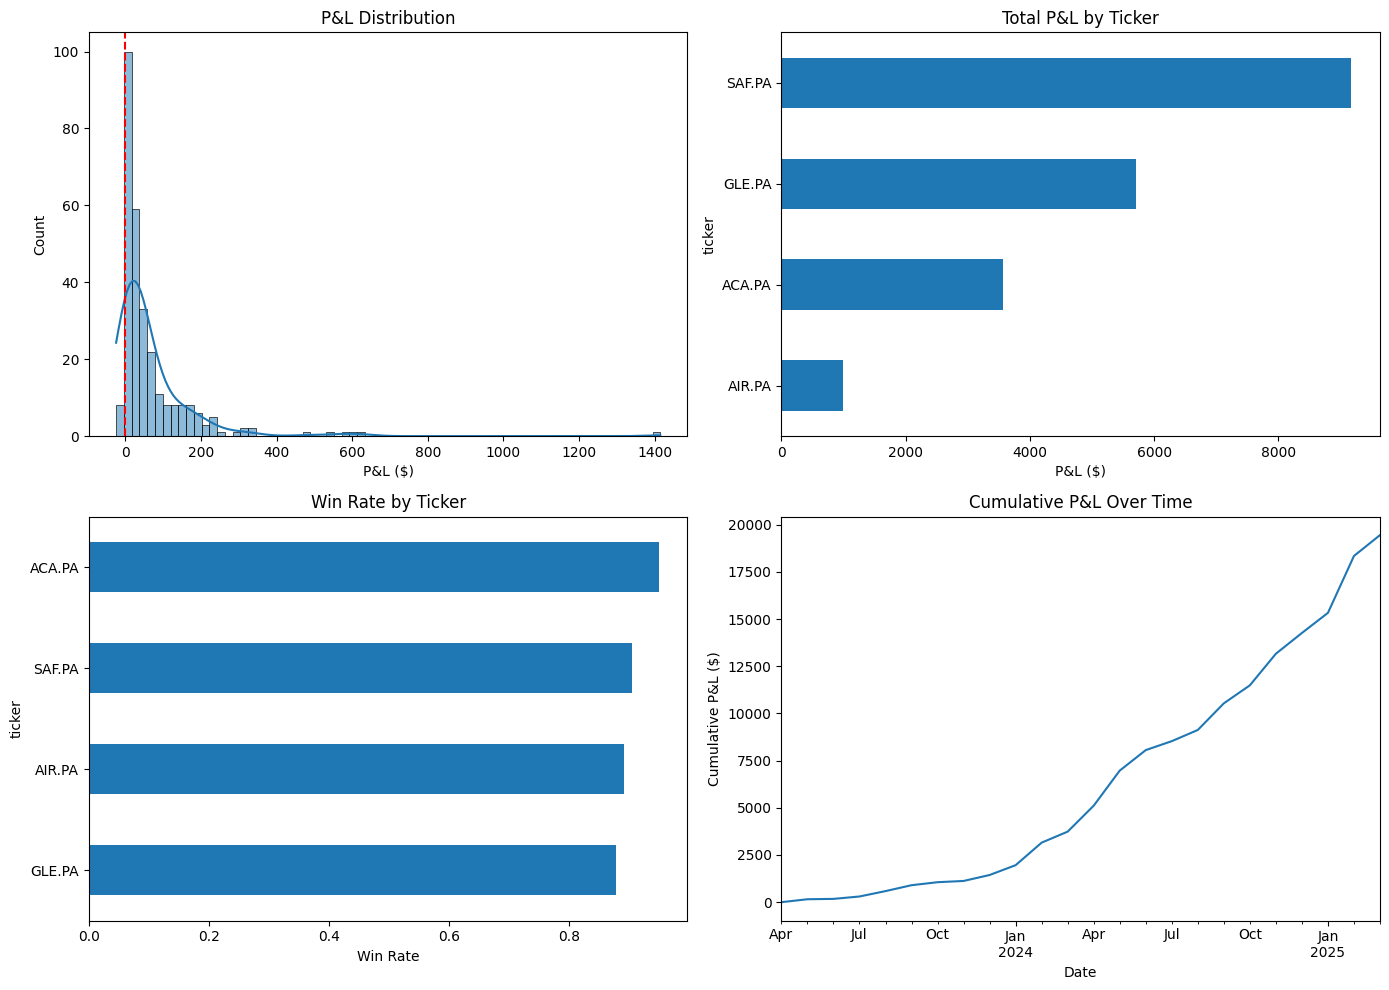

In [36]:
optimized_weights = performance_weighted_allocation(ticker_summary)
# Format the optimized weights to match the expected input format
optimized_tickers = pd.DataFrame({
    'Ticker': optimized_weights['Ticker'],
    'Weight': optimized_weights['Weight'],
    # Include any other columns your original best_tickers DataFrame had
    'Sharpe': best_tickers['Sharpe'],  # Keep original metrics if needed
    'Total_Return': best_tickers['Total_Return'],
    'Score': optimized_weights['Score']  # Add the new score
})

# Run the optimized backtest
optimized_metrics = backtest_portfolio(
    optimized_tickers,  # Use optimized weights
    enhanced_df,        # Same data as original backtest
    initial_capital=100000,
    transaction_cost=0.001,
    rebalance_freq=20,  # Consider extending this to reduce trading costs
    risk_per_trade=0.1
)

# Visualize optimized portfolio performance
visualize_portfolio_performance(optimized_metrics)

# Analyze detailed P&L
optimized_pnl_df, optimized_ticker_summary = analyze_pnl_details(optimized_metrics)

Portfolio optimization improved total returns by 24.95%
              Metric  Original  Optimized
0       Total Return    34.86%     68.51%
1  Annualized Return    17.00%     31.50%
2       Sharpe Ratio     -0.03       0.20
3       Max Drawdown    15.60%     20.23%
4           Win Rate     0.00%      0.00%
5          Total P&L  $3498.44  $19445.46
6        Trade Count      1087        623


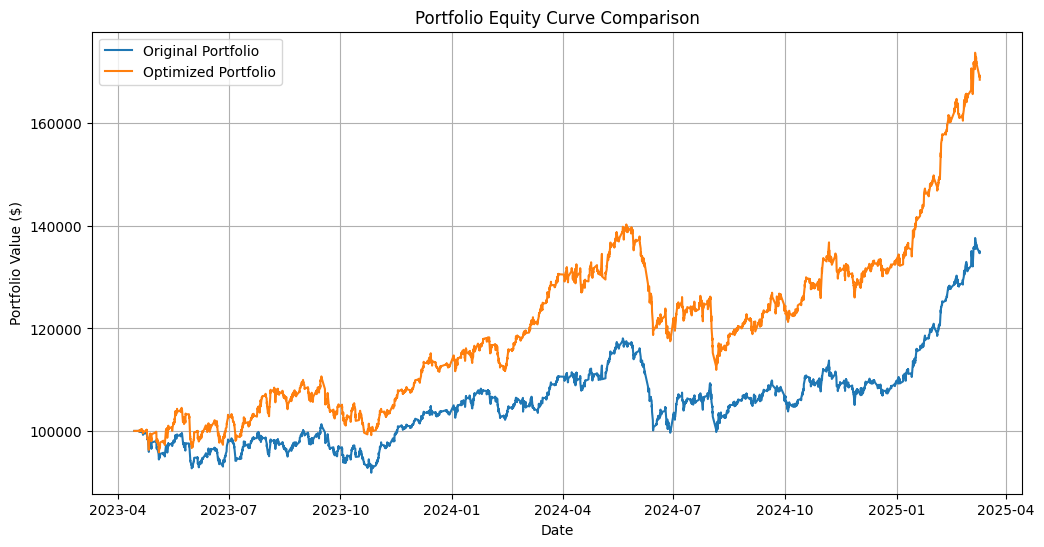

In [37]:
def compare_backtests(original_metrics, optimized_metrics):
    """
    Compare performance between original and optimized backtests
    """
    comparison = pd.DataFrame({
        'Metric': ['Total Return', 'Annualized Return', 'Sharpe Ratio', 
                   'Max Drawdown', 'Win Rate', 'Total P&L', 'Trade Count'],
        'Original': [f"{original_metrics['total_return']:.2%}",
                    f"{original_metrics['annualized_return']:.2%}",
                    f"{original_metrics['sharpe_ratio']:.2f}",
                    f"{original_metrics['max_drawdown']:.2%}",
                    f"{original_metrics['win_rate']:.2%}",
                    f"${sum(r['pnl'] for r in original_metrics['realized_pnl']):.2f}",
                    f"{len(original_metrics['trades'])}"],
        'Optimized': [f"{optimized_metrics['total_return']:.2%}",
                     f"{optimized_metrics['annualized_return']:.2%}",
                     f"{optimized_metrics['sharpe_ratio']:.2f}",
                     f"{optimized_metrics['max_drawdown']:.2%}",
                     f"{optimized_metrics['win_rate']:.2%}",
                     f"${sum(r['pnl'] for r in optimized_metrics['realized_pnl']):.2f}",
                     f"{len(optimized_metrics['trades'])}"]
    })
    
    # Calculate improvement percentages
    original_return = original_metrics['total_return']
    optimized_return = optimized_metrics['total_return']
    improvement = ((1 + optimized_return) / (1 + original_return) - 1) * 100
    
    print(f"Portfolio optimization improved total returns by {improvement:.2f}%")
    
    # Display comparison table
    return comparison

# Compare results
comparison_table = compare_backtests(portfolio_metrics, optimized_metrics)
print(comparison_table)

# Visualize equity curves for comparison
plt.figure(figsize=(12, 6))
plt.plot(portfolio_metrics['dates'], portfolio_metrics['equity_curve'], 
         label='Original Portfolio')
plt.plot(optimized_metrics['dates'], optimized_metrics['equity_curve'], 
         label='Optimized Portfolio')
plt.title('Portfolio Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()